In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

print(df.head())
print(df.info())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [4]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [5]:
df = df.dropna()

In [6]:
print("Dataset Shape:", df.shape)

print(df.describe())

Dataset Shape: (28638, 12)
         person_age  person_income  person_emp_length     loan_amnt  \
count  28638.000000   2.863800e+04       28638.000000  28638.000000   
mean      27.727216   6.664937e+04           4.788672   9656.493121   
std        6.310441   6.235645e+04           4.154627   6329.683361   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.948000e+04           2.000000   5000.000000   
50%       26.000000   5.595600e+04           4.000000   8000.000000   
75%       30.000000   8.000000e+04           7.000000  12500.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   28638.000000  28638.000000         28638.000000   
mean       11.039867      0.216600             0.169488   
std         3.229372      0.411935             0.106393   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000    

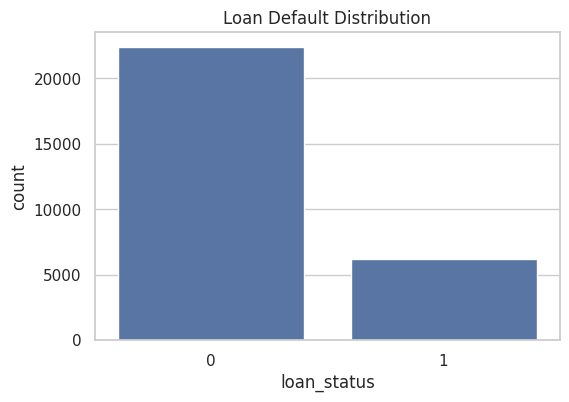

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='loan_status', data=df)

plt.title("Loan Default Distribution")

plt.savefig("loan_distribution.png")

plt.show()

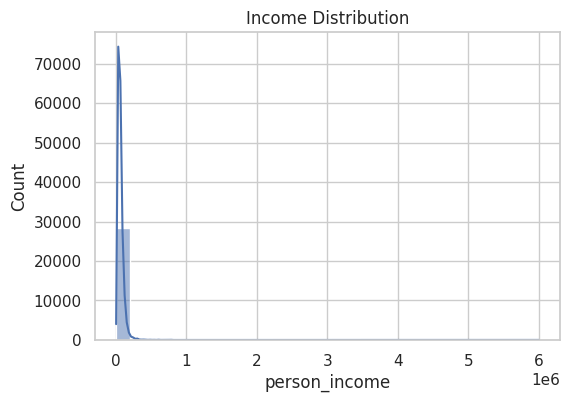

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(df["person_income"], bins=30, kde=True)

plt.title("Income Distribution")

plt.savefig("income_distribution.png")

plt.show()

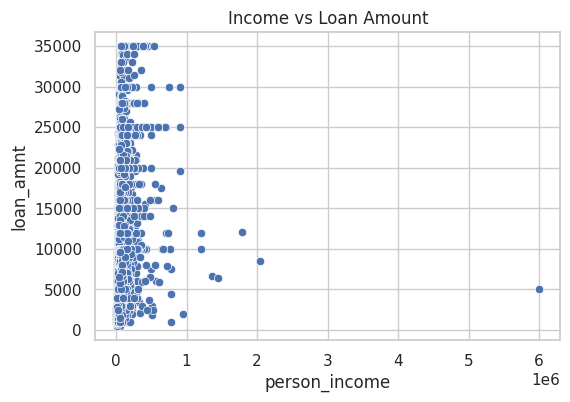

In [10]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="person_income", y="loan_amnt", data=df)

plt.title("Income vs Loan Amount")

plt.savefig("income_vs_loan.png")

plt.show()

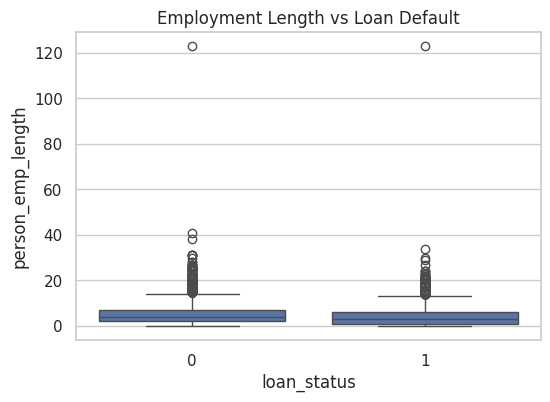

In [11]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status", y="person_emp_length", data=df)

plt.title("Employment Length vs Loan Default")

plt.savefig("employment_vs_default.png")

plt.show()

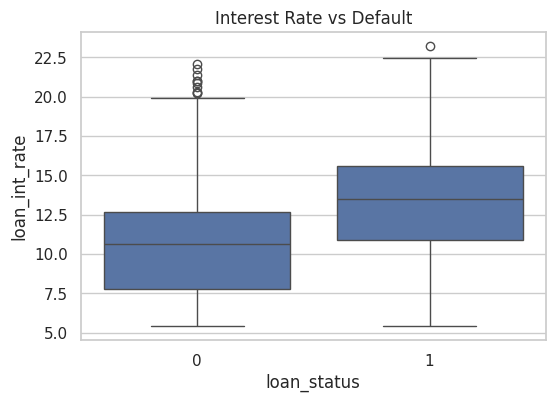

In [12]:
plt.figure(figsize=(6,4))

sns.boxplot(x="loan_status", y="loan_int_rate", data=df)

plt.title("Interest Rate vs Default")

plt.savefig("interest_vs_default.png")

plt.show()

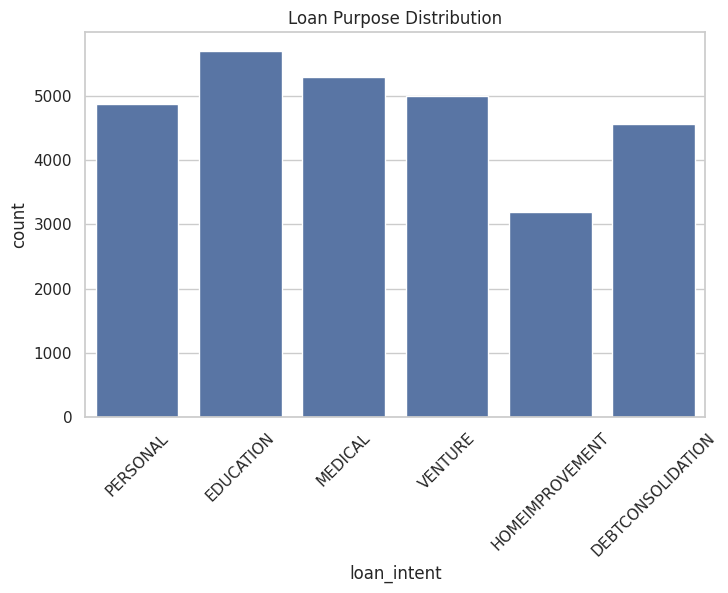

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x="loan_intent", data=df)

plt.xticks(rotation=45)

plt.title("Loan Purpose Distribution")

plt.savefig("loan_purpose.png")

plt.show()

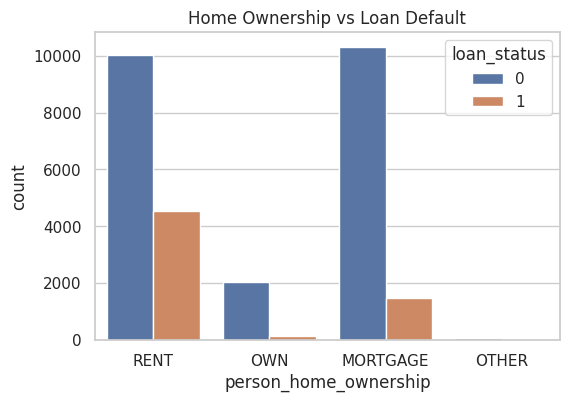

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="person_home_ownership", hue="loan_status", data=df)

plt.title("Home Ownership vs Loan Default")

plt.savefig("home_vs_default.png")

plt.show()

In [15]:
df["income_group"] = pd.cut(
    df["person_income"],
    bins=[0,30000,60000,100000,200000],
    labels=["Low","Medium","High","Very High"]
)

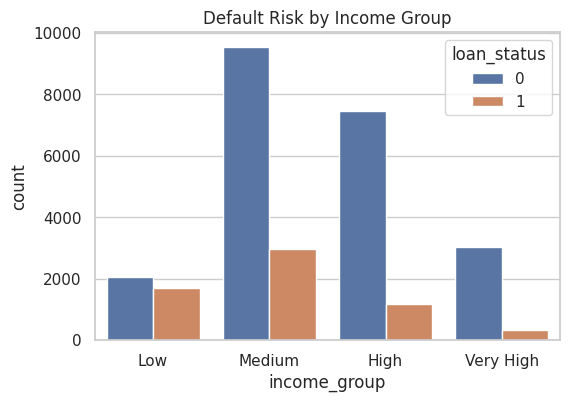

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="income_group", hue="loan_status", data=df)

plt.title("Default Risk by Income Group")

plt.savefig("default_by_income.png")

plt.show()

In [17]:
numeric_df = df.select_dtypes(include=np.number)

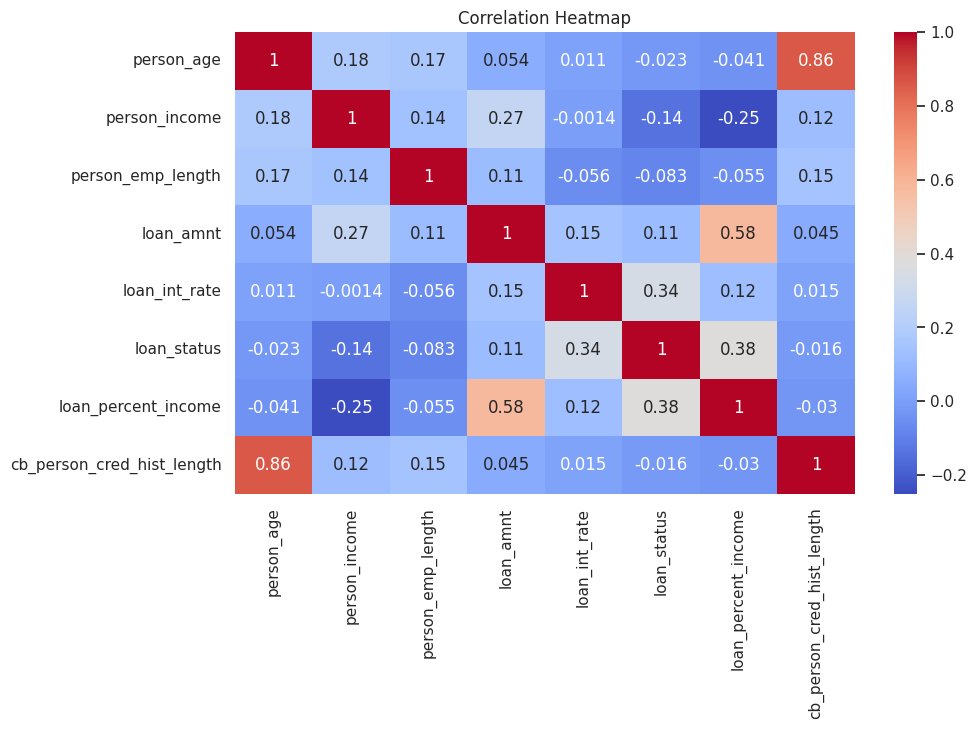

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()